# Regresión Polinomial — Predicción de Ventas Walmart

**Dataset:** Walmart.csv — 6,435 registros, 45 tiendas  
**Variable objetivo (Y):** Weekly_Sales (ventas semanales en USD)  
**Variables disponibles:**

| Columna | Tipo | Descripción |
|---|---|---|
| Store | Numérico (ID) | Número de tienda (1–45) |
| Date | Texto (fecha) | Semana del registro — hay que extraer info útil |
| Weekly_Sales | Numérico | Ventas de esa semana — lo que queremos predecir |
| Holiday_Flag | Binario (0/1) | ¿Es semana de feriado? Ya está en 0/1 |
| Temperature | Numérico | Temperatura promedio de esa semana (°F) |
| Fuel_Price | Numérico | Precio del combustible |
| CPI | Numérico | Índice de Precios al Consumidor — mide la inflación general |
| Unemployment | Numérico | Tasa de desempleo |

### ¿Qué es el CPI?
El CPI (Consumer Price Index / Índice de Precios al Consumidor) mide cuánto
cuestan en promedio los bienes y servicios básicos. Si el CPI sube, los
productos son más caros y la gente puede comprar menos.

### ¿Hay que binarizar todo?
No. Binarizar = convertir texto a 0/1. Solo se hace cuando hay texto:
- `Holiday_Flag` ya es 0/1 ✓  
- `Temperature`, `Fuel_Price`, `CPI`, `Unemployment` ya son números ✓  
- `Store` ya es número ✓  
- `Date` es texto → la convertimos extrayendo semana y mes

Lo que sí hay que hacer con los números es **normalizar** (escalarlos a [0,1]).

In [1]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. CARGAR DATOS
# ============================================================
df = pd.read_csv("Walmart.csv")

print("Dimensiones:", df.shape)
print("\nPrimeras filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())

Dimensiones: (6435, 8)

Primeras filas:
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

Tipos de datos:
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Valores nulos:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temper

In [3]:
# ============================================================
# 3. PREPARAR LA COLUMNA DATE
# ============================================================
# Date es texto (ej: '05-02-2010') y no sirve directo como número.
# La convertimos a fecha real y extraemos:
#   - month (mes 1-12): puede capturar estacionalidad (navidad, verano)
#   - week (semana 1-52): granularidad semanal
#   - year (año): posibles tendencias anuales
#
# Después ya no necesitamos la columna Date original.

df['Date']  = pd.to_datetime(df['Date'], dayfirst=True)
df['month'] = df['Date'].dt.month
df['week']  = df['Date'].dt.isocalendar().week.astype(int)
df['year']  = df['Date'].dt.year

df = df.drop(columns=['Date'])  # ya no la necesitamos

print("Columnas nuevas generadas: month, week, year")
print(df[['Store', 'month', 'week', 'year', 'Weekly_Sales']].head(10))

Columnas nuevas generadas: month, week, year
   Store  month  week  year  Weekly_Sales
0      1      2     5  2010    1643690.90
1      1      2     6  2010    1641957.44
2      1      2     7  2010    1611968.17
3      1      2     8  2010    1409727.59
4      1      3     9  2010    1554806.68
5      1      3    10  2010    1439541.59
6      1      3    11  2010    1472515.79
7      1      3    12  2010    1404429.92
8      1      4    13  2010    1594968.28
9      1      4    14  2010    1545418.53


In [4]:
# ============================================================
# 4. CORRELACIÓN DE PEARSON — ¿qué variables importan más?
# ============================================================
# Calculamos la correlación de cada variable con Weekly_Sales.
# Esto nos dice cuáles tienen más relación con las ventas.
#
# NOTA IMPORTANTE sobre este dataset:
# Las correlaciones son bajas en general — eso es normal.
# Significa que las ventas dependen de muchos factores combinados,
# no de uno solo. El modelo polinomial puede capturar esas relaciones
# no lineales mejor que el lineal.

columnas_numericas = ['Store', 'Holiday_Flag', 'Temperature',
                      'Fuel_Price', 'CPI', 'Unemployment',
                      'month', 'week', 'year', 'Weekly_Sales']

correlacion = (df[columnas_numericas]
               .corr()['Weekly_Sales']
               .drop('Weekly_Sales')
               .sort_values(key=abs, ascending=False))

print("Correlación con Weekly_Sales:")
print("=" * 50)
for col, val in correlacion.items():
    barra  = '█' * int(abs(val) * 40)
    signo  = '+' if val >= 0 else '-'
    sentido = '↑ ventas suben' if val > 0.05 else ('↓ ventas bajan' if val < -0.05 else '  poca relación')
    print(f"{col:<15} {signo}{abs(val):.3f}  {barra:<20}  {sentido}")

# Detección automática de la variable más influyente
variable_top    = correlacion.abs().idxmax()
correlacion_top = correlacion.abs().max()
print(f"\n→ Variable con mayor correlación: '{variable_top}' (r={correlacion_top:.3f})")
print("→ Las correlaciones son bajas: las ventas son influenciadas")
print("  por la combinación de variables, no por una sola.")

Correlación con Weekly_Sales:
Store           -0.335  █████████████         ↓ ventas bajan
Unemployment    -0.106  ████                  ↓ ventas bajan
month           +0.076  ███                   ↑ ventas suben
week            +0.074  ██                    ↑ ventas suben
CPI             -0.073  ██                    ↓ ventas bajan
Temperature     -0.064  ██                    ↓ ventas bajan
Holiday_Flag    +0.037  █                       poca relación
year            -0.018                          poca relación
Fuel_Price      +0.009                          poca relación

→ Variable con mayor correlación: 'Store' (r=0.335)
→ Las correlaciones son bajas: las ventas son influenciadas
  por la combinación de variables, no por una sola.


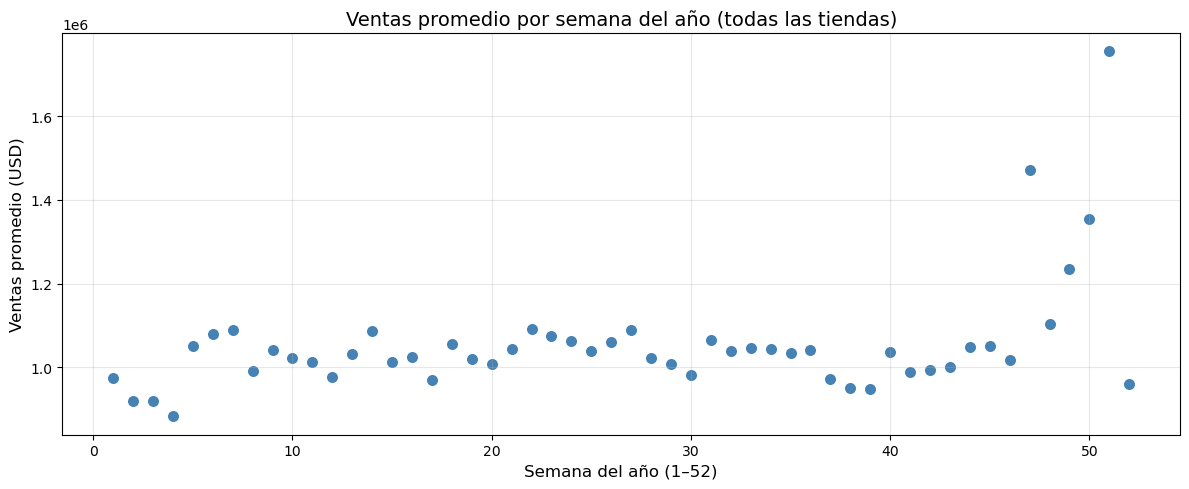


→ Si la curva no es recta, la regresión polinomial encajará mejor.


In [5]:
# ============================================================
# 5. VISUALIZACIÓN — Ventas promedio por semana del año
# ============================================================
# Igual que el ejercicio del seguro agrupaba por edad,
# aquí agrupamos por semana para ver la estacionalidad.
# ¿Suben las ventas en navidad? ¿Bajan en ciertos meses?

ventas_por_semana = (df.groupby('week')['Weekly_Sales']
                       .mean()
                       .reset_index())

plt.figure(figsize=(12, 5))
plt.scatter(ventas_por_semana['week'],
            ventas_por_semana['Weekly_Sales'],
            color='steelblue', edgecolors='white', s=80)
plt.title('Ventas promedio por semana del año (todas las tiendas)', fontsize=14)
plt.xlabel('Semana del año (1–52)', fontsize=12)
plt.ylabel('Ventas promedio (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\n→ Si la curva no es recta, la regresión polinomial encajará mejor.")

In [6]:
# ============================================================
# 6. SELECCIONAR VARIABLES X e y
# ============================================================
# Usamos las variables con mayor correlación + las que tienen
# sentido lógico para predecir ventas de supermercado.

features = ['Store', 'Holiday_Flag', 'Temperature',
            'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week']

X = df[features].values
y = df['Weekly_Sales'].values

print("Variables de entrada (X):", features)
print("Variable a predecir  (y): Weekly_Sales")
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Variables de entrada (X): ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week']
Variable a predecir  (y): Weekly_Sales
Forma de X: (6435, 8)
Forma de y: (6435,)


In [7]:
# ============================================================
# 7. NORMALIZACIÓN MIN-MAX
# ============================================================
# Las ventas van de $209,000 a $3,818,000 — escala enorme.
# Temperatura, CPI, desempleo tienen escalas completamente diferentes.
# Holiday_Flag ya es 0/1 pero igual se normaliza con .values por uniformidad.
#
# Guardamos min/max ANTES de normalizar para poder desnormalizar
# la predicción final y expresarla en dólares reales.

X_min = X.min(axis=0)   # mínimo de cada columna
X_max = X.max(axis=0)   # máximo de cada columna
y_min = y.min()
y_max = y.max()

print("Rangos ANTES de normalizar:")
for nombre, mn, mx in zip(features, X_min, X_max):
    print(f"  {nombre:<15}: {mn:.2f} – {mx:.2f}")
print(f"  {'Weekly_Sales':<15}: {y_min:.2f} – {y_max:.2f}")

X_norm = (X - X_min) / (X_max - X_min)
y_norm = (y - y_min) / (y_max - y_min)

print("\nNormalización aplicada. Todos los valores ahora en [0, 1].")

Rangos ANTES de normalizar:
  Store          : 1.00 – 45.00
  Holiday_Flag   : 0.00 – 1.00
  Temperature    : -2.06 – 100.14
  Fuel_Price     : 2.47 – 4.47
  CPI            : 126.06 – 227.23
  Unemployment   : 3.88 – 14.31
  month          : 1.00 – 12.00
  week           : 1.00 – 52.00
  Weekly_Sales   : 209986.25 – 3818686.45

Normalización aplicada. Todos los valores ahora en [0, 1].


In [8]:
# ============================================================
# 8. DIVIDIR EN ENTRENAMIENTO Y PRUEBA (80% / 20%)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_norm,
    test_size=0.2,
    random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} registros (80%)")
print(f"Prueba:         {X_test.shape[0]} registros (20%)")

Entrenamiento: 5148 registros (80%)
Prueba:         1287 registros (20%)


In [9]:
# ============================================================
# 9. COMPARAR GRADOS — encontrar el mejor y detectar over/underfitting
# ============================================================
# UNDERFITTING (ajuste insuficiente):
#   El modelo es demasiado simple para los datos.
#   R² train BAJO + R² test BAJO
#   → el modelo no aprende ni con los datos de entrenamiento
#   → pasa con degree=1 cuando la relación es curva
#
# BUEN AJUSTE:
#   R² train BUENO + R² test similar al train
#   → el modelo generaliza bien con datos nuevos
#
# OVERFITTING (sobreajuste):
#   El modelo memoriza los datos de entrenamiento pero falla con datos nuevos.
#   R² train MUY ALTO + R² test BAJO (diferencia grande entre ambos)
#   → pasa con degree muy alto (4, 5, 6...)
#   → como estudiar solo los exámenes pasados de memoria y reprobar el nuevo

print(f"{'Grado':<7} {'R² Train':>10} {'R² Test':>10} {'Diferencia':>12}  Diagnóstico")
print("-" * 65)

mejor_r2    = -999
mejor_grado = 1
resultados  = []

for grado in range(1, 5):
    modelo = Pipeline([
        ('poly', PolynomialFeatures(degree=grado, include_bias=False)),
        ('reg',  LinearRegression())
    ])
    modelo.fit(X_train, y_train)

    r2_train = r2_score(y_train, modelo.predict(X_train))
    r2_test  = r2_score(y_test,  modelo.predict(X_test))
    diff     = r2_train - r2_test

    if   diff > 0.1:           diagnostico = "⚠ OVERFITTING"
    elif r2_test < 0.3:        diagnostico = "⚠ UNDERFITTING"
    else:                      diagnostico = "✓ Buen ajuste"

    print(f"{grado:<7} {r2_train:>10.4f} {r2_test:>10.4f} {diff:>12.4f}  {diagnostico}")
    resultados.append((grado, r2_train, r2_test))

    if r2_test > mejor_r2:
        mejor_r2    = r2_test
        mejor_grado = grado

print(f"\n→ Mejor grado encontrado: {mejor_grado} (R² test = {round(mejor_r2, 4)})")

Grado     R² Train    R² Test   Diferencia  Diagnóstico
-----------------------------------------------------------------
1           0.1474     0.1542      -0.0068  ⚠ UNDERFITTING
2           0.2838     0.3064      -0.0226  ✓ Buen ajuste
3           0.4491     0.4335       0.0156  ✓ Buen ajuste
4           0.6315     0.5607       0.0708  ✓ Buen ajuste

→ Mejor grado encontrado: 4 (R² test = 0.5607)


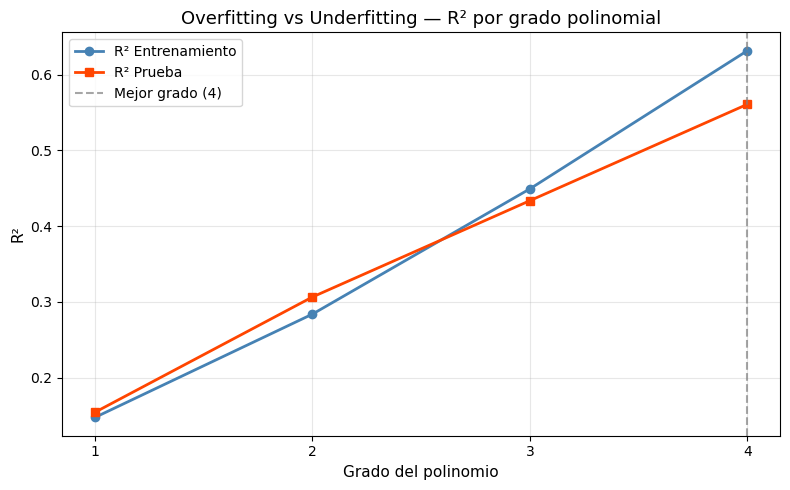

→ Si las dos líneas están juntas → buen ajuste
→ Si train sube y test baja      → overfitting
→ Si ambas están muy bajas       → underfitting


In [10]:
# ============================================================
# 10. GRÁFICA — R² train vs R² test por grado
# ============================================================
# Esta gráfica muestra visualmente dónde empieza el overfitting:
# cuando train sigue subiendo pero test empieza a bajar.

grados    = [r[0] for r in resultados]
r2_trains = [r[1] for r in resultados]
r2_tests  = [r[2] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(grados, r2_trains, marker='o', color='steelblue',  label='R² Entrenamiento', linewidth=2)
plt.plot(grados, r2_tests,  marker='s', color='orangered',  label='R² Prueba',         linewidth=2)
plt.axvline(x=mejor_grado, color='gray', linestyle='--', alpha=0.7, label=f'Mejor grado ({mejor_grado})')
plt.title('Overfitting vs Underfitting — R² por grado polinomial', fontsize=13)
plt.xlabel('Grado del polinomio', fontsize=11)
plt.ylabel('R²', fontsize=11)
plt.xticks(grados)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("→ Si las dos líneas están juntas → buen ajuste")
print("→ Si train sube y test baja      → overfitting")
print("→ Si ambas están muy bajas       → underfitting")

In [11]:
# ============================================================
# 11. ENTRENAR MODELO FINAL Y EVALUAR MÉTRICAS
# ============================================================
modelo_final = Pipeline([
    ('poly', PolynomialFeatures(degree=mejor_grado, include_bias=False)),
    ('reg',  LinearRegression())
])
modelo_final.fit(X_train, y_train)

predicciones = modelo_final.predict(X_test)

mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
r2  = r2_score(y_test, predicciones)

# Desnormalizar MAE para expresarlo en dólares reales
mae_real = mae * (y_max - y_min)

print("============================")
print(f"MÉTRICAS — degree={mejor_grado}")
print("============================")
print(f"MAE:          {round(mae, 4)}  (normalizado)")
print(f"MAE real:     ${round(mae_real, 2)} USD en promedio")
print(f"MSE:          {round(mse, 4)}")
print(f"R²:           {round(r2, 4)}")
print(f"\n→ El modelo explica el {round(r2 * 100, 1)}% de la variación en ventas.")

MÉTRICAS — degree=4
MAE:          0.0814  (normalizado)
MAE real:     $293749.46 USD en promedio
MSE:          0.0109
R²:           0.5607

→ El modelo explica el 56.1% de la variación en ventas.


In [12]:
# ============================================================
# 12. PREDECIR VENTAS DE UNA TIENDA — semana siguiente
# ============================================================
# Ejemplo: predecir ventas de tienda 1, semana 10 de marzo
# ↓↓ CAMBIAR los valores según el ejercicio ↓↓

nuevo = {
    'Store':        1,
    'Holiday_Flag': 0,      # 0 = semana normal, 1 = feriado
    'Temperature':  55.0,   # °F
    'Fuel_Price':   3.1,
    'CPI':          211.0,
    'Unemployment': 8.1,
    'month':        3,      # marzo
    'week':         10
}

# Convertir a array y normalizar con los rangos del dataset
X_nuevo      = np.array([[nuevo[f] for f in features]])
X_nuevo_norm = (X_nuevo - X_min) / (X_max - X_min)

# Predecir y desnormalizar
pred_norm = modelo_final.predict(X_nuevo_norm)
pred_real = (pred_norm[0] * (y_max - y_min)) + y_min

print("============================")
print("PREDICCIÓN NUEVA SEMANA")
print("============================")
for k, v in nuevo.items():
    print(f"  {k:<15}: {v}")
print(f"\nVentas estimadas: ${round(pred_real, 2)} USD")

PREDICCIÓN NUEVA SEMANA
  Store          : 1
  Holiday_Flag   : 0
  Temperature    : 55.0
  Fuel_Price     : 3.1
  CPI            : 211.0
  Unemployment   : 8.1
  month          : 3
  week           : 10

Ventas estimadas: $1666481.6 USD


---
## 📌 Over y Underfitting — resumen visual

```
UNDERFITTING          BUEN AJUSTE           OVERFITTING
degree muy bajo       degree adecuado       degree muy alto

datos: • • • •        datos: • • • •        datos: • • • •
modelo: ________      modelo: ___/‾‾        modelo: ~∿∿∿∿~

R² train: bajo        R² train: bueno       R² train: muy alto
R² test:  bajo        R² test:  similar     R² test:  bajo
                                            ← AQUÍ ESTÁ EL PROBLEMA
```
El modelo con overfitting memorizó los datos de entrenamiento
pero no sabe predecir datos nuevos. Como alguien que memoriza
las respuestas del examen pasado pero no entiende el tema.

## 📌 Adaptaciones clave vs el ejercicio del seguro

| | Seguro | Walmart |
|---|---|---|
| Columnas de texto | sex, smoker, region | Date (→ extraer mes/semana) |
| Binarización | sex, smoker con .map() | No aplica |
| One-Hot | region con get_dummies | No aplica |
| Variable más correlacionada | smoker (0.787) | Store (-0.335) |
| Reto principal | Incluir género | Manejar fechas correctamente |